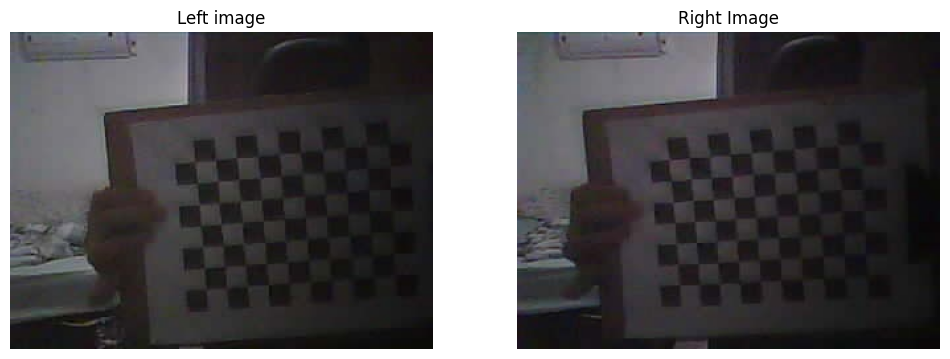

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

def show_images(left_image, right_image, left_image_title='Left image', right_image_title='Right Image', color_map='viridis'):
  plt.figure(figsize=(12, 6))
  plt.subplot(1, 2, 1)
  plt.imshow(left_image, cmap=color_map)
  plt.title(left_image_title)
  plt.axis('off')

  plt.subplot(1, 2, 2)
  plt.imshow(right_image, cmap=color_map)
  plt.title(right_image_title)
  plt.axis('off')

  plt.show()

right_image_path = "stereoCalibrationRight/15.jpg"
left_image_path = "stereoCalibrationLeft/15.jpg"

chessboard_size = (8 - 1 , 11 - 1) # internal corners of a 8 rows x 12 cols
chessboard_tile_size = 20 # 30 mm tiles


right_image = cv2.imread(right_image_path)
left_image = cv2.imread(left_image_path)
right_image = cv2.cvtColor(right_image,cv2.COLOR_BGR2RGB)
left_image = cv2.cvtColor(left_image,cv2.COLOR_BGR2RGB)

show_images(left_image, right_image)

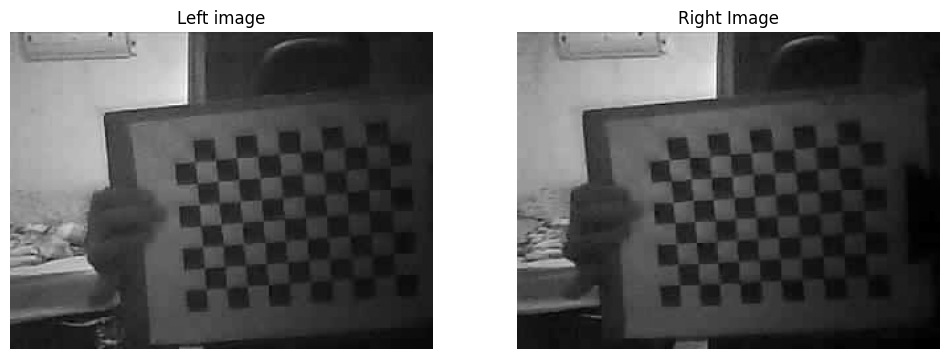

In [ ]:
left_grayscale = cv2.cvtColor(left_image, cv2.COLOR_RGB2GRAY)
right_grayscale = cv2.cvtColor(right_image, cv2.COLOR_RGB2GRAY)

show_images(left_grayscale, right_grayscale, color_map='gray')

In [ ]:
left_ret, left_corners = cv2.findChessboardCorners(left_grayscale, chessboard_size, None)
right_ret, right_corners = cv2.findChessboardCorners(right_grayscale, chessboard_size, None)
print(f"Chessboard corners detected in right image: {right_ret}")
print(f"Chessboard corners detected in left image: {left_ret}")

Chessboard corners detected in right image: True
Chessboard corners detected in left image: True


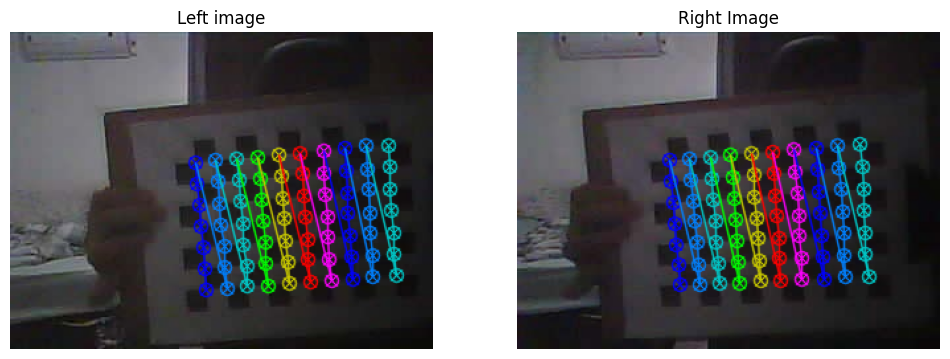

In [ ]:
left_obj_points = [] # 3D points in real-world space for left image
left_img_points = [] # 2D points in image plane for left image

right_obj_points = [] # 3D points in real-world space for right image
right_img_points = [] # 2D points in image plane for right image


# Temp points array
objp = np.zeros((chessboard_size[1]*chessboard_size[0], 3), np.float32)
objp[:, :2] = np.indices(chessboard_size).T.reshape(-1, 2)
objp *= chessboard_tile_size


criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

left_corners_refined = cv2.cornerSubPix(left_grayscale, left_corners, (11, 11), (-1, -1), criteria)

left_img_points.append(left_corners_refined)
left_obj_points.append(objp)

left_img_with_corners = cv2.drawChessboardCorners(left_image.copy(), chessboard_size, left_corners_refined, left_ret)

right_corners_refined = cv2.cornerSubPix(right_grayscale, right_corners, (11, 11), (-1, -1), criteria)

right_img_points.append(right_corners_refined)
right_obj_points.append(objp)

right_img_with_corners = cv2.drawChessboardCorners(right_image.copy(), chessboard_size, right_corners_refined, right_ret)

show_images(left_img_with_corners, right_img_with_corners)

In [ ]:
left_ret, left_mtx, left_dist, left_rvecs, left_tvecs = cv2.calibrateCamera(left_obj_points, left_img_points, left_grayscale.shape[::-1], None, None)
print("Left Camera Intrinsic Matrix:\n", left_mtx)
print("\nLeft Camera Distortion Coefficients:\n", left_dist.ravel())

Left Camera Intrinsic Matrix:
 [[215.13318846   0.          93.5782896 ]
 [  0.         226.63513725  65.73268324]
 [  0.           0.           1.        ]]

Left Camera Distortion Coefficients:
 [ 0.05801261 -0.06139669 -0.00103907  0.00175567  0.02620448]


In [ ]:
right_ret, right_mtx, right_dist, right_rvecs, right_tvecs = cv2.calibrateCamera(right_obj_points, right_img_points, right_grayscale.shape[::-1], None, None)
print("Right CameraIntrinsic Matrix:\n", right_mtx)
print("\nRight Camera Distortion Coefficients:\n", right_dist.ravel())

Right CameraIntrinsic Matrix:
 [[138.62456657   0.         189.93226427]
 [  0.         141.03519503 134.30354745]
 [  0.           0.           1.        ]]

Right Camera Distortion Coefficients:
 [ 2.53008670e-01 -1.30326364e+00 -2.74864385e-04  5.60302448e-04
  1.92943662e+00]


In [ ]:
left_img_points_reprojected, _ = cv2.projectPoints(objp, left_rvecs[0], left_tvecs[0], left_mtx, left_dist)
error = cv2.norm(left_corners_refined, left_img_points_reprojected, cv2.NORM_L2) / len(left_img_points_reprojected)
print(f"\nLeft Camera Reprojection Error: {error:.4f}")


Left Camera Reprojection Error: 0.0590


In [ ]:
right_img_points_reprojected, _ = cv2.projectPoints(objp, right_rvecs[0], right_tvecs[0], right_mtx, right_dist)
error = cv2.norm(right_corners_refined, right_img_points_reprojected, cv2.NORM_L2) / len(right_img_points_reprojected)
print(f"\nRight Camera Reprojection Error: {error:.4f}")


Right Camera Reprojection Error: 0.0525


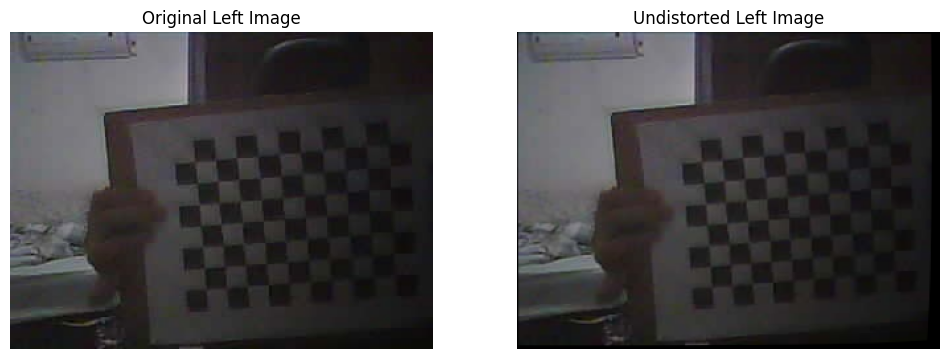

In [ ]:
left_undistorted_img = cv2.undistort(left_image, left_mtx, left_dist)

show_images(left_image, left_undistorted_img, left_image_title='Original Left Image', right_image_title='Undistorted Left Image')

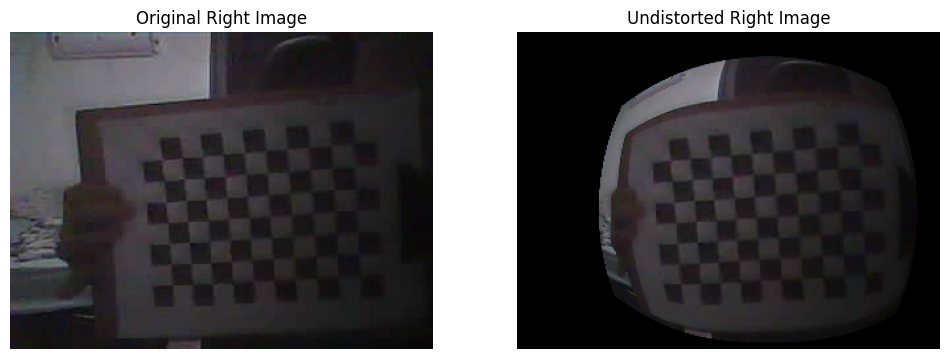

In [ ]:
right_undistorted_img = cv2.undistort(right_image, right_mtx, right_dist)

show_images(right_image, right_undistorted_img, left_image_title='Original Right Image', right_image_title='Undistorted Right Image')